## Executive Summary

This analysis examines 4 years of Superstore sales data (9,994 orders) 
to identify drivers of profitability across products, regions, and 
customer segments.

Key findings:
- Technology is the highest margin category, led by Copiers at 31.72% 
  margin. Furniture underperforms across all segments, with Tables and 
  Bookcases generating losses of $17,725 and $3,472 respectively.
- West region leads in profit ($$108,418) with the lowest average 
  discount (10.9%). Central region generates the second highest sales 
  but the lowest profit ($39,706), driven by a 24% average discount 
  rate, more than double West's rate.
- Revenue shows strong seasonality, with September, November and 
  December consistently outperforming other months every year. January 
  and February are consistently the weakest months.
- Consumer segment generates the highest total profit but the lowest 
  margin (11.20%), due to heavy discounting on high volume Office 
  Supplies purchases. Home Office segment is the most margin efficient 
  at 14.29%.
- Business is growing year over year: revenue grew from $484K in 2014 
  to $733K in 2017, a 51% increase.

Recommendation: Cap Central region discounts at 15%, restructure 
Furniture category pricing especially for Tables and Bookcases, and 
redirect marketing focus toward growing the Home Office segment.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/superstore.csv', encoding='latin-1')

In [4]:
#First Inspection

In [5]:
print(df.shape)

(9994, 21)


In [6]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [7]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
#Fixing Date Coloumn

In [11]:
df['Order Date']= pd.to_datetime(df['Order Date'])

In [12]:
df['Ship Date']= pd.to_datetime(df['Ship Date'])

In [13]:
print(df['Order Date'].dtype)

datetime64[ns]


In [14]:
#Handling Duplicate

In [15]:
print(df.duplicated().sum())

0


In [16]:
#standard method to remove the exact duplicate
df=df.drop_duplicates()

In [17]:
#to drop the null values
df['Postal Code']=df['Postal Code'].fillna(0).astype(int)

In [18]:
#Feature Engieering

In [19]:
#coloumn Profit Margin %
df['Profit Margin']=(df['Profit']/df['Sales']*100).round(2)

In [20]:
#coloumn Shipping Date
df['Shipping Date']=(df['Ship Date']-df['Order Date']).dt.days

In [21]:
#coloumn order month
df['Order Month']=df['Order Date'].dt.to_period('M')

.dt.month gives just the number 3

If data spans multiple years, March 2020 and March 2021 would merge together. .to_period('M') keeps year and month together, so grouping works correctly across years.

In [22]:
#Save the clean data 

In [23]:
df.to_csv('../data/superstore_clean.csv', index=False)
print(f'Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns')

Clean dataset: 9994 rows, 24 columns


index=False 

Without it, pandas writes the row numbers (0, 1, 2...) as an extra first column in CSV.

In [24]:
#Setup=loading data into SQLite and Running the different query to answer Business Questions

In [25]:
import sqlite3
from sqlalchemy import create_engine

In [26]:
df['Order Month'] = df['Order Month'].astype(str) #Fix the Period type issue before writing, object to string

engine=create_engine('sqlite:///../data/superstore.db')
#create_engine() a function from SQLAlchemy library that creates a connection engine to a database.

df.to_sql('sales', engine, if_exists='replace', index=False)

conn=sqlite3.connect('../data/superstore.db')
# .connect() - opens a direct connection to the database file.
# conn -  stores this connection. pd.read_sql("query", conn)

#engine  →  SQLAlchemy engine  →  used by pandas to WRITE data  (df.to_sql)
#conn    →  sqlite3 connection →  used by pandas to READ data   (pd.read_sql)

Writes entire clean DataFrame into that database as a table named 'sales'

Two Objects
engine- used by pandas to write data into the database
conn-used by pandas to read query results back out

#Query 1 - Profit by Category and Sub-Category

Business question: Which categories and sub-categories are most profitable?

In [27]:
q1 = pd.read_sql("""
    SELECT Category, [Sub-Category],
    ROUND(SUM(Sales),2)   AS total_sales,
    ROUND(SUM(Profit),2)  AS total_profit,
    ROUND(AVG([Profit Margin]),2) AS avg_margin
    FROM sales
    GROUP BY Category, [Sub-Category]
    ORDER BY total_profit DESC""", conn)

print(q1.head(10))

          Category Sub-Category  total_sales  total_profit  avg_margin
0       Technology      Copiers    149528.03      55617.82       31.72
1       Technology       Phones    330007.05      44515.73       11.92
2       Technology  Accessories    167380.32      41936.64       21.82
3  Office Supplies        Paper     78479.21      34053.57       42.56
4  Office Supplies      Binders    203412.73      30221.76      -19.96
5        Furniture       Chairs    328449.10      26590.17        4.39
6  Office Supplies      Storage    223843.61      21278.83        8.91
7  Office Supplies   Appliances    107532.16      18138.01      -15.69
8        Furniture  Furnishings     91705.16      13059.14       13.71
9  Office Supplies    Envelopes     16476.40       6964.18       42.31


Above figure shows top 10 Total Profit Sub category

Some Finding are as follows

1 Copiers is the star-
Copiers made only 149K in sales but 55K in profit at 31.72% margin. Phones made 330K in sales but only $44K profit at 11.92% margin. Copiers sells less but earns more efficiently. This is the power of margin over raw profit.

2 Binders is a red flag -
Row 4 - Binders has 203K in sales, $30K profit, but -19.96% avg margin. A negative average margin means many individual Binder orders are being sold at a loss. High volume, losing money per sale. Classic over-discounting problem.

3 Appliances is worse -
Row 7 - Appliances shows -15.69% avg margin. Another sub-category where discounts are destroying value. 

4 Technology dominates the top 3 -
Rows 0, 1, 2 are all Technology. This category is clearly the profit engine of the business.

In [28]:
print(q1.tail(10))

           Category Sub-Category  total_sales  total_profit  avg_margin
7   Office Supplies   Appliances    107532.16      18138.01      -15.69
8         Furniture  Furnishings     91705.16      13059.14       13.71
9   Office Supplies    Envelopes     16476.40       6964.18       42.31
10  Office Supplies          Art     27118.79       6527.79       25.16
11  Office Supplies       Labels     12486.31       5546.25       42.97
12       Technology     Machines    189238.63       3384.76       -7.20
13  Office Supplies    Fasteners      3024.28        949.52       29.92
14  Office Supplies     Supplies     46673.54      -1189.10       11.20
15        Furniture    Bookcases    114880.00      -3472.56      -12.66
16        Furniture       Tables    206965.53     -17725.48      -14.77


Finding from the above figures are 

1 Tables is the biggest loss maker
Row 16 - Tables made 206K in sales - the highest in this list - but lost $17,725 in profit at -14.77% margin. This means the more Tables they sell, the more money they lose. A dangerous situation.

2 Bookcases is also losing money
Row 15 - 114K in sales, -3,472 loss, -12.66% margin. Another Furniture sub-category destroying value.

3 Machines is quietly bleeding
Row 12 — Technology sub-category with 189K sales but only $3,384 profit at -7.20% margin. Surprising because Technology overall was the top performer. Machines is the weak link inside that category.

#Query 2 - Regional Performance with CASE WHEN

Business question: Which regions underperform? Bucket them into tiers.

In [29]:
q2 = pd.read_sql("""
    SELECT Region,
    ROUND(SUM(Sales),2)  AS total_sales,
    ROUND(SUM(Profit),2) AS total_profit,
    CASE
        WHEN SUM(Profit) > 50000 THEN 'High'
        WHEN SUM(Profit) > 10000 THEN 'Medium'
        ELSE 'Low'
    END AS profit_tier
    FROM sales
    GROUP BY Region
    ORDER BY total_profit DESC""", conn)
print(q2.head(10))

    Region  total_sales  total_profit profit_tier
0     West    725457.82     108418.45        High
1     East    678781.24      91522.78        High
2    South    391721.91      46749.43      Medium
3  Central    501239.89      39706.36      Medium


Findings from the above figures

Central region generates $$501K in sales - second highest - but only $39K in profit, the lowest of all four regions. Despite higher sales volume than South, Central earns 7K less in profit, strongly suggesting excessive discounting is the root cause of underperformance.

In [30]:
q2_discount = pd.read_sql("""
    SELECT Region,
    ROUND(AVG(Discount)*100, 1) AS avg_discount_pct,
    ROUND(SUM(Profit), 2)       AS total_profit
    FROM sales
    GROUP BY Region
    ORDER BY avg_discount_pct DESC""", conn)

print(q2_discount)

    Region  avg_discount_pct  total_profit
0  Central              24.0      39706.36
1    South              14.7      46749.43
2     East              14.5      91522.78
3     West              10.9     108418.45


Central is giving 24% average discount - more than double West's 10.9%. That is not a small difference. That is a completely different pricing strategy.
And the result - West earns $$108K profit while Central earns only $39K despite selling more.

#Query 3 - Monthly Revenue Trend

Business question: How does revenue trend month over month?

In [31]:
q3 = pd.read_sql("""
    SELECT strftime('%Y-%m', [Order Date]) AS order_month,
    ROUND(SUM(Sales),2)  AS monthly_revenue,
    ROUND(SUM(Profit),2) AS monthly_profit,
    COUNT(DISTINCT [Order ID]) AS num_orders 
    FROM sales
    GROUP BY order_month
    ORDER BY order_month ASC""", conn)
print(q3.head(36))

   order_month  monthly_revenue  monthly_profit  num_orders
0      2014-01         14236.90         2450.19          32
1      2014-02          4519.89          862.31          28
2      2014-03         55691.01          498.73          71
3      2014-04         28295.35         3488.84          66
4      2014-05         23648.29         2738.71          69
5      2014-06         34595.13         4976.52          66
6      2014-07         33946.39         -841.48          65
7      2014-08         27909.47         5318.10          72
8      2014-09         81777.35         8328.10         130
9      2014-10         31453.39         3448.26          78
10     2014-11         78628.72         9292.13         151
11     2014-12         69545.62         8983.57         141
12     2015-01         18174.08        -3281.01          29
13     2015-02         11951.41         2813.85          36
14     2015-03         38726.25         9732.10          79
15     2015-04         34195.21         

Finding from the above figure 

Revenue shows consistent seasonality - September, October, November, and December spike every year while January consistently drops. The business should plan inventory and marketing around this predictable cycle. Overall revenue trend is growing year over year.

Now below will try to find out "Which Month of Year is Consistently Highest"

In [32]:
q3_seasonal = pd.read_sql("""
    SELECT 
    month_number,
    ROUND(AVG(monthly_revenue), 2) AS avg_revenue
    FROM (
        SELECT 
        strftime('%Y-%m', [Order Date]) AS order_month,
        strftime('%m', [Order Date])    AS month_number,
        SUM(Sales)                      AS monthly_revenue
        FROM sales
        GROUP BY order_month
    )
    GROUP BY month_number
    ORDER BY month_number ASC""", conn)

print(q3_seasonal)

   month_number  avg_revenue
0            01     23731.21
1            02     14937.81
2            03     51251.37
3            04     34440.53
4            05     38757.20
5            06     38179.67
6            07     36809.52
7            08     39761.02
8            09     76912.49
9            10     50080.75
10           11     88115.27
11           12     81323.38


Now below will try to find out "Year over Year Comparison"

In [33]:
q3_yearly = pd.read_sql("""
    SELECT 
    strftime('%Y', [Order Date]) AS year,
    ROUND(SUM(Sales), 2)      AS total_revenue,
    ROUND(SUM(Profit), 2)     AS total_profit,
    COUNT(DISTINCT [Order ID])   AS total_orders
    FROM sales
    GROUP BY year
    ORDER BY year ASC""", conn)

print(q3_yearly)

   year  total_revenue  total_profit  total_orders
0  2014      484247.50      49543.97           969
1  2015      470532.51      61618.60          1038
2  2016      609205.60      81795.17          1315
3  2017      733215.26      93439.27          1687


Now below will try to find out "Best and Worst Month Ever"

In [34]:
q3_best = pd.read_sql("""
    SELECT 
    strftime('%Y-%m', [Order Date]) AS order_month,
    ROUND(SUM(Sales), 2)            AS monthly_revenue,
    ROUND(SUM(Profit), 2)           AS monthly_profit
    FROM sales
    GROUP BY order_month
    ORDER BY monthly_revenue DESC
    LIMIT 5""", conn)

print("TOP 5 BEST MONTHS")
print(q3_best)

q3_worst = pd.read_sql("""
    SELECT 
    strftime('%Y-%m', [Order Date]) AS order_month,
    ROUND(SUM(Sales), 2)            AS monthly_revenue,
    ROUND(SUM(Profit), 2)           AS monthly_profit
    FROM sales
    GROUP BY order_month
    ORDER BY monthly_revenue ASC
    LIMIT 5""", conn)

print("TOP 5 WORST MONTHS")
print(q3_worst)

TOP 5 BEST MONTHS
  order_month  monthly_revenue  monthly_profit
0     2017-11        118447.82         9690.10
1     2016-12         96999.04        17885.31
2     2017-09         87866.65        10991.56
3     2017-12         83829.32         8483.35
4     2014-09         81777.35         8328.10
TOP 5 WORST MONTHS
  order_month  monthly_revenue  monthly_profit
0     2014-02          4519.89          862.31
1     2015-02         11951.41         2813.85
2     2014-01         14236.90         2450.19
3     2015-01         18174.08        -3281.01
4     2016-01         18542.49         2824.82


Findings from the above figure

The business shows strong and predictable seasonality. November 2017 was the best month ever at $118K revenue. January and February are consistently the weakest months every year. The company should increase marketing spend in October to capture the November-December spike earlier, and reduce inventory costs in January-February to protect margins during the demand drought.

#Query 4 - Discount Impact by Segment

Business question: Which segments are heavily discounted and still losing profit?

In [35]:
q4 = pd.read_sql("""
    SELECT Segment,
    ROUND(AVG(Discount)*100, 1)      AS avg_discount_pct,
    ROUND(SUM(Profit),2)             AS total_profit,
    ROUND(AVG([Profit Margin]),2)  AS avg_margin
    FROM sales
    GROUP BY Segment
    HAVING AVG(Discount) > 0
    ORDER BY avg_discount_pct DESC""", conn)
print(q4.head(10))

       Segment  avg_discount_pct  total_profit  avg_margin
0    Corporate              15.8      91979.13       12.12
1     Consumer              15.8     134119.21       11.20
2  Home Office              14.7      60298.68       14.29


Findings from the above figure 

1 Consumer is the largest but least efficient segment -
Consumer generates the highest total profit at $134K - but has the lowest margin at 11.20%. This means Consumer is profitable only because of sheer volume. Per sale, it is the weakest performer.

2 Home Office is the hidden gem -
Home Office has the lowest total profit at $60K - but the highest margin at 14.29%. It receives the least discount at 14.7% and earns the most per sale. If the business grew this segment, profit would grow faster than costs.

3 Corporate and Consumer get identical discounts -
Both at exactly 15.8% - yet Corporate earns 12.12% margin versus Consumer's 11.20%. Same discount, different margin. This means Consumer is buying lower margin products. To support this, running a querry "q_segment_category" below to identify. 

4 Every segment gets discounted
HAVING AVG(Discount) > 0 filtered for segments with discounts - and all three passed. No segment is buying at full price. The entire business runs on discounts.

In [36]:
q4_segment_category = pd.read_sql("""
    SELECT Segment, Category,
    ROUND(SUM(Sales),2)           AS total_sales,
    ROUND(AVG([Profit Margin]),2) AS avg_margin
    FROM sales
    GROUP BY Segment, Category
    ORDER BY Segment, avg_margin DESC""", conn)

print(q4_segment_category)

       Segment         Category  total_sales  avg_margin
0     Consumer       Technology    406399.90       15.27
1     Consumer  Office Supplies    363952.14       12.88
2     Consumer        Furniture    391049.31        3.04
3    Corporate       Technology    246450.12       15.54
4    Corporate  Office Supplies    230676.46       13.75
5    Corporate        Furniture    229019.79        4.58
6  Home Office       Technology    183304.02       16.69
7  Home Office  Office Supplies    124418.43       16.57
8  Home Office        Furniture    121930.70        5.21


Findings from the above figures 

1 Consumer does buy less margin product -more Furniture - ₹162K more. But the margin difference is small — 3.04% vs 4.58%. Not the full explanation.

2  Home Office is Genuinely Different- Home Office gets better margins on the same categories than Consumer. Same products, better margins. This means Home Office customers receive fewer discounts - confirming they are the most profitable segment to serve.

3 Consumer Office Supplies is the Biggest Problem- Consumer buys the most Office Supplies - ₹363K - but at the lowest margin 12.88%. Heavy discounting on high volume = significant profit leakage.

4 Furniture is Weak Across All Segments- No segment makes good money on Furniture. This is a category-level problem - not a segment or discount problem. The products themselves have structural cost or pricing issues.

5 Technology is the Profit Engine Everywhere- Every segment makes strong margins on Technology. This category performs consistently regardless of who is buying it.

Technology drives profitability across all three customer segments with consistent 15-17% margins. Furniture underperforms universally - no segment achieves above 5.21% margin - indicating a structural pricing or cost problem at the category level, not a discount issue. Home Office is the most margin-efficient segment at 16.69% on Technology and 16.57% on Office Supplies. Consumer segment generates highest revenue but lowest margins due to heavy discounting on high-volume Office Supplies purchases. Recommendation: grow Home Office segment, restructure Furniture pricing, and cap Consumer discounts on Office Supplies.

# Visualisation

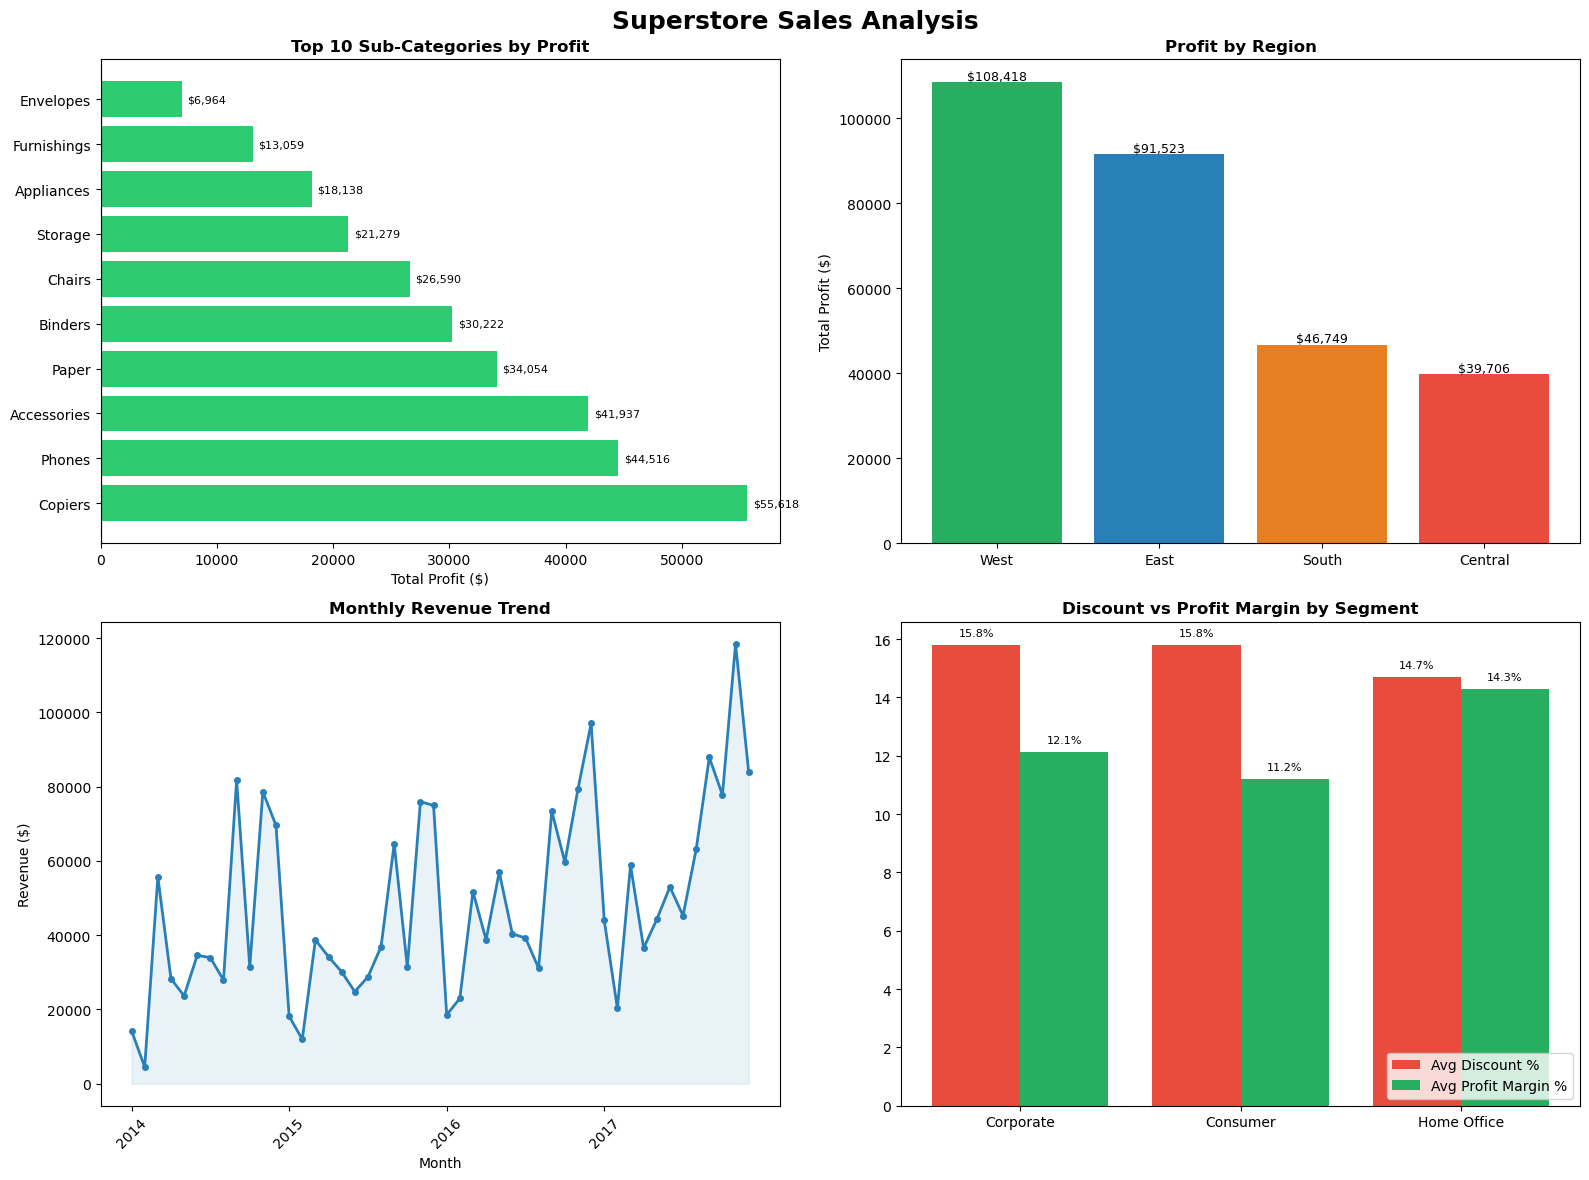

In [39]:
import matplotlib.pyplot as plt

# Grid setup
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Superstore Sales Analysis', fontsize=18, fontweight='bold')

# Chart 1 - Top left
ax1 = axes[0, 0]
top10 = q1.nlargest(10, 'total_profit')
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top10['total_profit']]
bars=ax1.barh(top10['Sub-Category'], top10['total_profit'], color=colors)
ax1.set_title('Top 10 Sub-Categories by Profit', fontweight='bold')
ax1.set_xlabel('Total Profit ($)')
ax1.axvline(0, color='black', linewidth=0.8)

#Adding Profit figure in the Horizontal Sub Category
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 500, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}', va='center', fontsize=8)

# Chart 2 - Top right
ax2 = axes[0, 1]
colors2 = ['#27ae60', '#2980b9', '#e67e22', '#e74c3c']
ax2.bar(q2['Region'], q2['total_profit'], color=colors2)
ax2.set_title('Profit by Region', fontweight='bold')
ax2.set_ylabel('Total Profit ($)')
for i, val in enumerate(q2['total_profit']):
    ax2.text(i, val + 500, f'${val:,.0f}', ha='center', fontsize=9)


# Chart 3 - Bottom left
ax3 = axes[1, 0]
ax3.plot(range(len(q3)), q3['monthly_revenue'],
         marker='o', color='#2980b9', linewidth=2, markersize=4)
ax3.fill_between(range(len(q3)), q3['monthly_revenue'],
                 alpha=0.1, color='#2980b9')
ax3.set_title('Monthly Revenue Trend', fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Revenue ($)')
ax3.tick_params(axis='x', rotation=45)

# Add first month of each year as label
ax3.set_xticks([0, 12, 24, 36])
ax3.set_xticklabels(['2014', '2015', '2016', '2017'])

# Chart 4 - Bottom right
ax4 = axes[1, 1]
x = range(len(q4))
ax4.bar(x, q4['avg_discount_pct'],
        width=0.4, label='Avg Discount %',
        color='#e74c3c', align='center')
ax4.bar([i + 0.4 for i in x], q4['avg_margin'],
        width=0.4, label='Avg Profit Margin %',
        color='#27ae60', align='center')
ax4.set_xticks([i + 0.2 for i in x])
ax4.set_xticklabels(q4['Segment'])
ax4.set_title('Discount vs Profit Margin by Segment', fontweight='bold')
ax4.legend(loc='lower right') #displays the colour legend using the 'label='

for bar in ax4.patches: #ax4.patches -  accesses ALL bar objects drawn on ax4, works for grouped bars
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=8)

# Save and show
plt.tight_layout()
plt.savefig('../outputs/sales_analysis_4panel.png', dpi=150, bbox_inches='tight')
plt.show()

Extended analysis chart saved


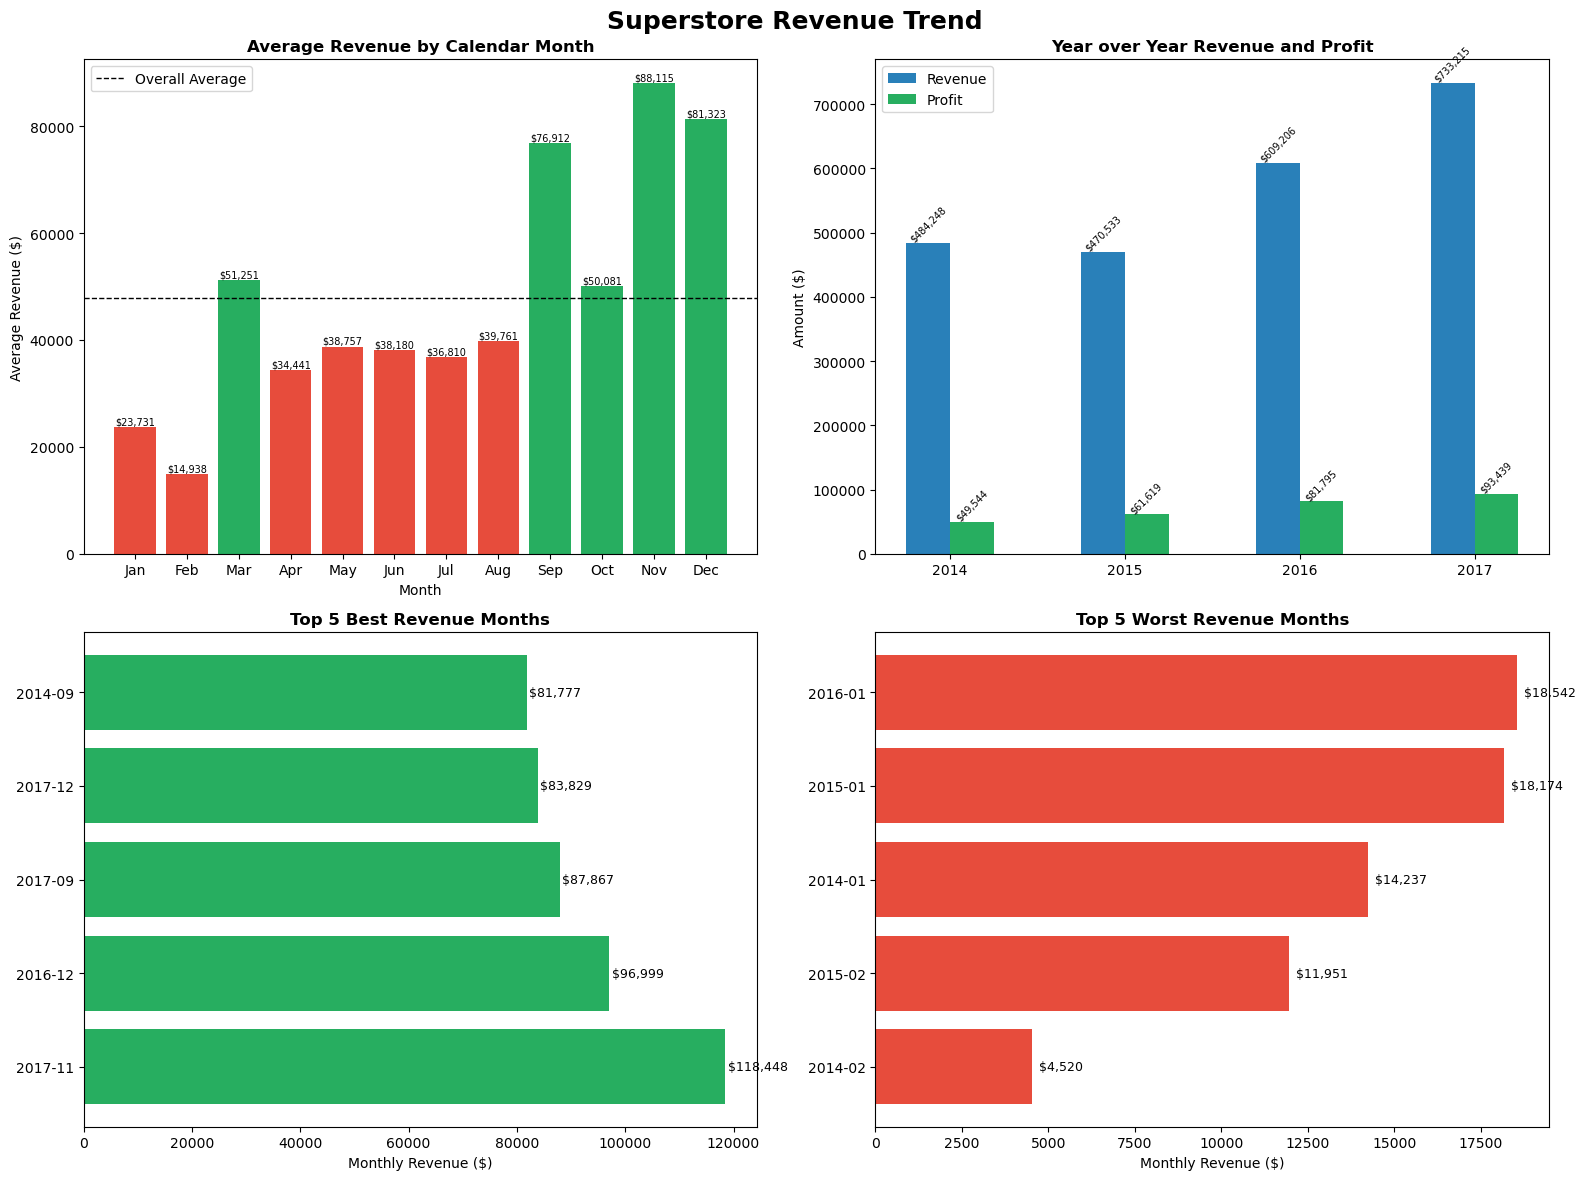

In [40]:
# Revenue Trend
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('Superstore Revenue Trend', fontsize=18, fontweight='bold')

#  Chart 1  Seasonality (Top Left)
ax_s1 = axes2[0, 0]

month_names = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct','Nov','Dec']

season_colors = ['#e74c3c' if x < 40000 else '#27ae60'
                 for x in q3_seasonal['avg_revenue']]

s1_bars = ax_s1.bar(month_names, q3_seasonal['avg_revenue'], color=season_colors)

ax_s1.set_title('Average Revenue by Calendar Month', fontweight='bold')
ax_s1.set_xlabel('Month')
ax_s1.set_ylabel('Average Revenue ($)')
ax_s1.axhline(q3_seasonal['avg_revenue'].mean(),
              color='black', linewidth=1,
              linestyle='--', label='Overall Average')
ax_s1.legend(loc='upper left')

for bar in s1_bars:
    height = bar.get_height()
    ax_s1.text(bar.get_x() + bar.get_width()/2,
               height + 500,
               f'${height:,.0f}',
               ha='center', fontsize=7)


#  Chart 2  Year over Year (Top Right) 
ax_s2 = axes2[0, 1]

x_yr = range(len(q3_yearly))

rev_bars = ax_s2.bar(x_yr,
                     q3_yearly['total_revenue'],
                     width=0.25,
                     label='Revenue',
                     color='#2980b9',
                     align='center')

prof_bars = ax_s2.bar([i + 0.25 for i in x_yr],
                      q3_yearly['total_profit'],
                      width=0.25,
                      label='Profit',
                      color='#27ae60',
                      align='center')

ax_s2.set_xticks([i + 0.125 for i in x_yr])
ax_s2.set_xticklabels(q3_yearly['year'])
ax_s2.set_title('Year over Year Revenue and Profit', fontweight='bold')
ax_s2.set_ylabel('Amount ($)')
ax_s2.legend(loc='upper left')

for bar in rev_bars:
    height = bar.get_height()
    ax_s2.text(bar.get_x() + bar.get_width()/2,
               height + 2000,
               f'${height:,.0f}',
               ha='center', fontsize=7, rotation=45)

for bar in prof_bars:
    height = bar.get_height()
    ax_s2.text(bar.get_x() + bar.get_width()/2,
               height + 2000,
               f'${height:,.0f}',
               ha='center', fontsize=7, rotation=45)


#  Chart 3  Best 5 Months (Bottom Left)
ax_s3 = axes2[1, 0]

best_bars = ax_s3.barh(q3_best['order_month'],
                       q3_best['monthly_revenue'],
                       color='#27ae60')

ax_s3.set_title('Top 5 Best Revenue Months', fontweight='bold')
ax_s3.set_xlabel('Monthly Revenue ($)')

for bar in best_bars:
    width = bar.get_width()
    ax_s3.text(width + 500,
               bar.get_y() + bar.get_height()/2,
               f'${width:,.0f}',
               va='center', fontsize=9)


#  Chart 4  Worst 5 Months (Bottom Right)
ax_s4 = axes2[1, 1]

worst_bars = ax_s4.barh(q3_worst['order_month'],
                        q3_worst['monthly_revenue'],
                        color='#e74c3c')

ax_s4.set_title('Top 5 Worst Revenue Months', fontweight='bold')
ax_s4.set_xlabel('Monthly Revenue ($)')

for bar in worst_bars:
    width = bar.get_width()
    ax_s4.text(width + 200,
               bar.get_y() + bar.get_height()/2,
               f'${width:,.0f}',
               va='center', fontsize=9)


#  Save and Show
plt.tight_layout()
plt.savefig('../outputs/Revenue_Trend.png', dpi=150, bbox_inches='tight')
print("Extended analysis chart saved")
plt.show()

# PLOTLY INTERACTIVE DASHBOARD

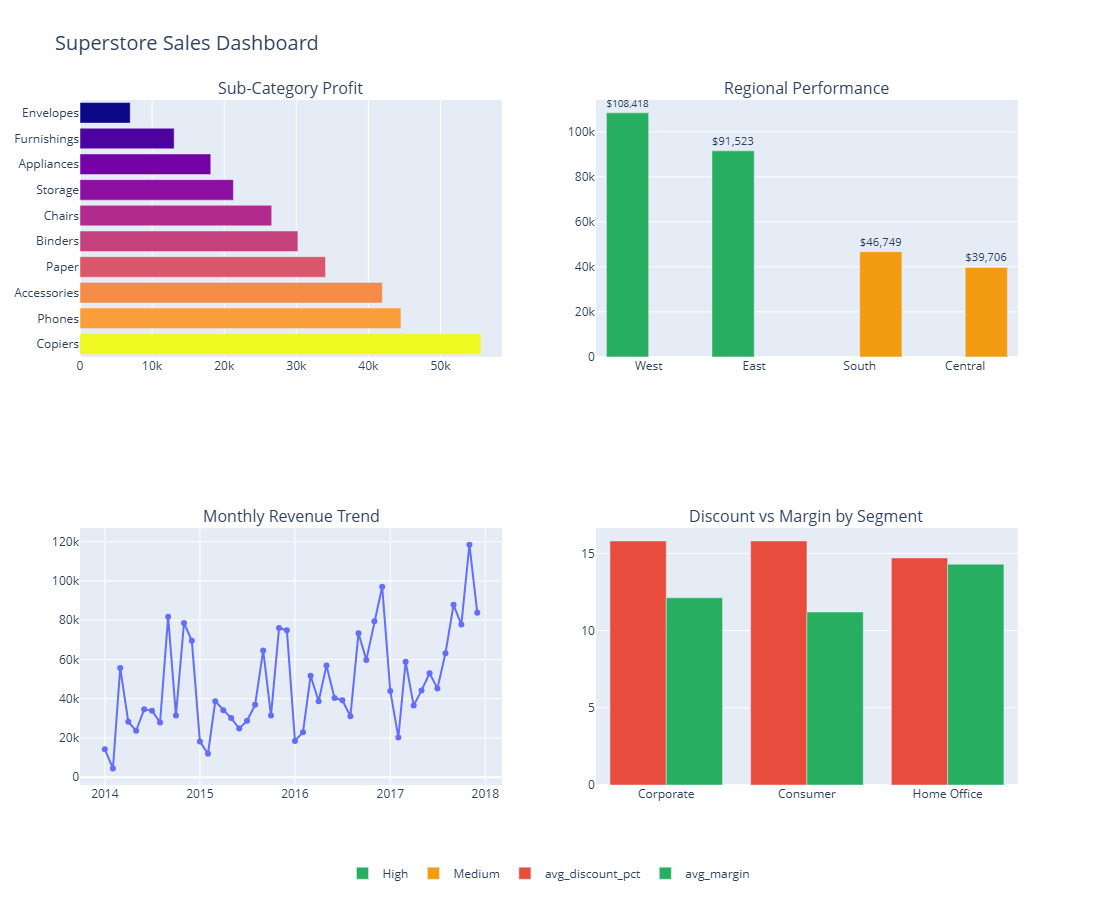

Dashboard saved to outputs folder


In [65]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#  Chart 1 Sub-Category Profit (Top Left)
fig1 = px.bar(
    q1.nlargest(10, 'total_profit'),
    x='total_profit',
    y='Sub-Category',
    orientation='h',
    color='total_profit',
    color_continuous_scale='RdYlGn',
)

# Chart 2 Regional Performance (Top Right) 
fig2 = px.bar(
    q2,
    x='Region',
    y='total_profit',
    color='profit_tier',
    text='total_profit',
    color_discrete_map={
        'High':   '#27ae60',
        'Medium': '#f39c12',
        'Low':    '#e74c3c'
    }
)
fig2.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')

# Chart 3 Monthly Revenue Trend (Bottom Left)
fig3 = px.line(
    q3,
    x='order_month',
    y='monthly_revenue',
    markers=True,
)


#Chart 4 Discount vs Margin by Segment (Bottom Right)
fig4 = px.bar(
    q4,
    x='Segment',
    y=['avg_discount_pct', 'avg_margin'],
    barmode='group',
    title='Discount vs Profit Margin by Segment',
    color_discrete_map={
        'avg_discount_pct': '#e74c3c',
        'avg_margin':       '#27ae60'
    }
)

# Combine Into One Dashboard
dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Sub-Category Profit',
        'Regional Performance',
        'Monthly Revenue Trend',
        'Discount vs Margin by Segment'
    ]
)

for trace in fig1.data:
    dashboard.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    dashboard.add_trace(trace, row=1, col=2)

for trace in fig3.data:
    dashboard.add_trace(trace, row=2, col=1)

for trace in fig4.data:
    dashboard.add_trace(trace, row=2, col=2)

dashboard.update_layout(
    height=900,
    title_text='Superstore Sales Dashboard',
    title_font_size=20,
    showlegend=True,
    coloraxis_showscale=False,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.15,
        xanchor='center',
        x=0.5
    )
)

dashboard.show()

# ── Save as HTML
dashboard.write_html('../outputs/dashboard.html')
print("Dashboard saved to outputs folder")